# Lab 06 – Solutions
**Topics:** Hough Line / Circle Transform · SIFT (object recognition, asset tracking, panorama) · Wavelet anomaly detection · Boundary detection

| # | Task | Main technique |
|---|------|----------------|
| 1 | Computer Screen Detection in a Computer Lab | Canny + **Hough Line Transform** |
| 2 | Asset Tracking in a Computer Lab | **SIFT** + homography |
| 3 | Anomaly Detection in Sensor Data | **Wavelet transform** (denoising + residuals) |
| 4 | Object Recognition (Using Video) | **SIFT** + FLANN + homography on video frames |
| 5 | Your Panoramic Image | **SIFT** + homography stitching |
| 6 | Lane Detection | Canny + ROI + **Hough Line Transform** |
| 7 | Coins Detection and Counting | **Hough Circle Transform** |
| 8 | Smart Security System | Background subtraction + contour/boundary detection |

### A note on the data
The lab sheet does not ship with image/video files, so every task **generates its own synthetic test data** with OpenCV/NumPy. This makes the notebook run end-to-end with no extra files. Each task that reads an image has a variable like `IMAGE_PATH`; set it to your own file and the same pipeline will run on your real data (thresholds may need small tuning).

Run the first cell once (imports and helpers), then any task independently.

## 0. Setup & shared helpers
**What this cell does**
- Imports OpenCV, NumPy, Matplotlib and PyWavelets (`pip install opencv-contrib-python pywavelets matplotlib`).
- `show()` – displays a BGR image correctly in Matplotlib (OpenCV uses BGR, Matplotlib expects RGB).
- `make_texture()` – creates a random but smooth coloured texture. **SIFT needs corners/blobs to work with**, so flat colours give no keypoints; textured synthetic images give plenty.
- `place()` – pastes a template into a scene after scaling and rotating it (used to simulate objects at different scales and orientations).
- `sift`, `ratio_matches()` – a shared SIFT detector and **Lowe's ratio test** matcher: a match is kept only if its best distance is clearly smaller (here < 0.75×) than the second-best, which removes ambiguous matches.

In [1]:
import os, math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

np.random.seed(42)
FONT = cv2.FONT_HERSHEY_SIMPLEX
print("OpenCV version:", cv2.__version__)

def show(img, title="", figsize=(8, 6), cmap=None):
    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or "gray")
    plt.title(title); plt.axis("off"); plt.show()

def show_grid(imgs, titles, cols=3, figsize=(15, 8)):
    rows = math.ceil(len(imgs) / cols)
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if im.ndim == 3 else im, cmap=None if im.ndim == 3 else "gray")
        plt.title(t, fontsize=10); plt.axis("off")
    plt.tight_layout(); plt.show()

def make_texture(h, w, seed=0, blur=3, mix_gray=0.0):
    # random colour noise -> gaussian blur -> contrast stretch = blobby texture with many SIFT keypoints
    rng = np.random.default_rng(seed)
    img = rng.integers(0, 256, (h, w, 3), dtype=np.uint8)
    img = cv2.GaussianBlur(img, (0, 0), blur)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    if mix_gray > 0:
        img = cv2.addWeighted(img, 1 - mix_gray, np.full_like(img, 128), mix_gray, 0)
    return img

def place(scene, tmpl, center, scale=1.0, angle=0.0):
    # paste `tmpl` into `scene` (in place) at `center`, scaled and rotated
    h, w = tmpl.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += center[0] - w / 2
    M[1, 2] += center[1] - h / 2
    size = (scene.shape[1], scene.shape[0])
    warped = cv2.warpAffine(tmpl, M, size)
    mask = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, size)
    scene[mask > 0] = warped[mask > 0]
    return scene

sift = cv2.SIFT_create()

def ratio_matches(des1, des2, ratio=0.75):
    # Lowe's ratio test with a brute-force L2 matcher
    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return []
    pairs = cv2.BFMatcher(cv2.NORM_L2).knnMatch(des1, des2, k=2)
    return [p[0] for p in pairs if len(p) == 2 and p[0].distance < ratio * p[1].distance]

OpenCV version: 4.13.0


---
# Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)

### Idea
A computer screen is a **rectangle**, i.e. four straight edges (2 horizontal + 2 vertical). The **Hough Line Transform** finds straight lines by letting every edge pixel "vote" for all lines passing through it; lines with many votes are real lines.

### Pipeline
1. **Grayscale → Gaussian blur → Canny** to get a clean edge map.
2. **`cv2.HoughLinesP`** (probabilistic Hough) returns line *segments* `(x1,y1,x2,y2)`.
3. Keep only **near-horizontal and near-vertical** segments (screen borders) – this discards diagonal clutter.
4. Draw the kept segments on a blank mask, **dilate** them so segments of the same border join, and find **external contours**. The bounding box of every contour = the boundary of one screen/monitor.
5. **ON/OFF status:** measure the mean brightness of the *central* part of each box. A lit screen is bright, a switched-off one is dark.
6. **Missing screens (anomaly):** the camera is fixed, so each desk has a known slot position. If no detected screen lies in a slot, that screen is reported as **MISSING**.

The synthetic lab has 2 rows × 4 desks: some screens ON, some OFF, and one removed.

Hough segments found: 46


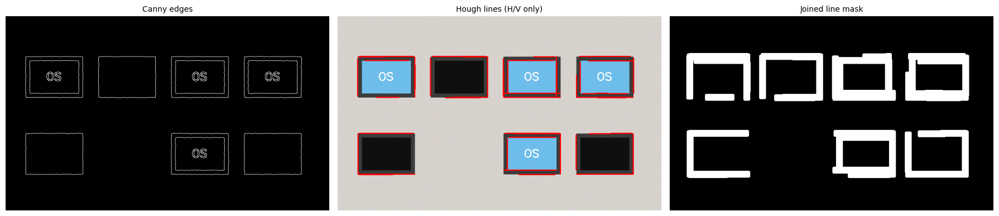

In [2]:
IMAGE_PATH = None      # e.g. "lab.jpg" -> note: SLOTS below must then be calibrated to your camera view
H1, W1 = 480, 800
SLOTS = [(r, c, (120 + 180 * c, 150 + 190 * r)) for r in range(2) for c in range(4)]   # (row, col, centre)
TRUE_STATE = {(0,0):"on", (0,1):"off", (0,2):"on", (0,3):"on",
              (1,0):"off", (1,1):"missing", (1,2):"on", (1,3):"off"}

def make_lab_image():
    img = np.full((H1, W1, 3), (205, 210, 215), np.uint8)               # light wall / desk
    for r, c, (cx, cy) in SLOTS:
        st = TRUE_STATE[(r, c)]
        if st == "missing":
            continue
        x0, y0, x1, y1 = cx - 70, cy - 50, cx + 70, cy + 50
        cv2.rectangle(img, (x0, y0), (x1, y1), (60, 60, 60), -1)          # bezel
        col = (235, 190, 110) if st == "on" else (15, 15, 15)             # screen glass
        cv2.rectangle(img, (x0 + 10, y0 + 10), (x1 - 10, y1 - 10), col, -1)
        if st == "on":
            cv2.putText(img, "OS", (cx - 20, cy + 8), FONT, 0.9, (255, 255, 255), 2)
    noise = np.random.normal(0, 4, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

lab = cv2.imread(IMAGE_PATH) if IMAGE_PATH and os.path.exists(IMAGE_PATH) else make_lab_image()

# 1) edges
gray = cv2.cvtColor(lab, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# 2) Hough line segments
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=60, minLineLength=50, maxLineGap=10)
print("Hough segments found:", 0 if lines is None else len(lines))

# 3) keep only near-horizontal / near-vertical segments
line_mask = np.zeros_like(gray)
vis_lines = lab.copy()
for x1, y1, x2, y2 in lines[:, 0]:
    ang = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))
    if ang < 5 or ang > 175 or 85 < ang < 95:
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, 3)
        cv2.line(vis_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# 4) join segments, find one contour per monitor
joined = cv2.dilate(line_mask, np.ones((7, 7), np.uint8), iterations=2)
contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
screens = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if 80 < w < 250 and 60 < h < 200:                  # plausible monitor size
        screens.append((x, y, w, h))

show_grid([edges, vis_lines, joined], ["Canny edges", "Hough lines (H/V only)", "Joined line mask"], cols=3, figsize=(18, 5))

Slot (row,col)  Status
(0, 0)          ON
(0, 1)          OFF
(0, 2)          ON
(0, 3)          ON
(1, 0)          OFF
(1, 1)          MISSING
(1, 2)          ON
(1, 3)          OFF


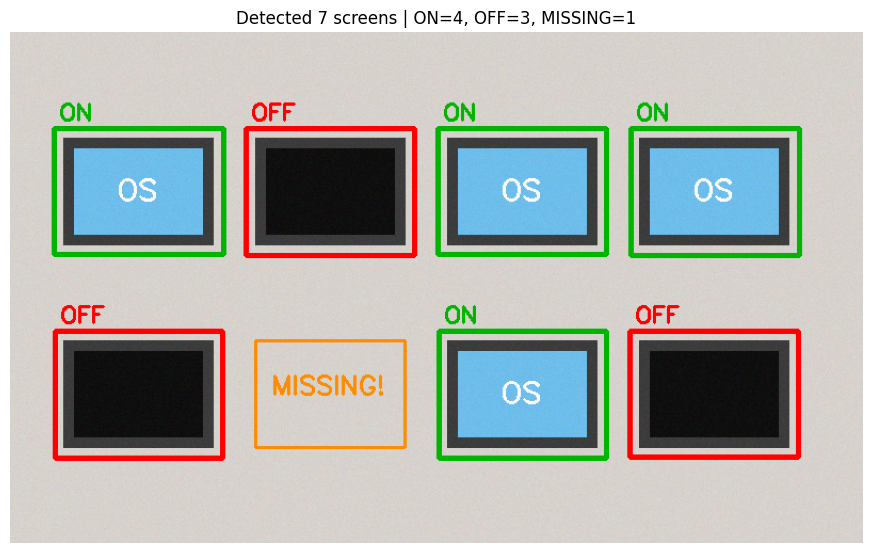

In [3]:
# 5) ON / OFF classification and 6) missing-screen detection
result = lab.copy()
status = {}
for (x, y, w, h) in screens:
    centre_roi = gray[y + h // 4: y + 3 * h // 4, x + w // 4: x + 3 * w // 4]
    brightness = centre_roi.mean()
    is_on = brightness > 80
    colour = (0, 180, 0) if is_on else (0, 0, 255)
    cv2.rectangle(result, (x, y), (x + w, y + h), colour, 3)
    cv2.putText(result, "ON" if is_on else "OFF", (x + 5, y - 8), FONT, 0.7, colour, 2)
    cx, cy = x + w // 2, y + h // 2
    for r, c, (sx, sy) in SLOTS:
        if abs(cx - sx) < 50 and abs(cy - sy) < 50:
            status[(r, c)] = "ON" if is_on else "OFF"

print(f"{'Slot (row,col)':<16}{'Status'}")
for r, c, (sx, sy) in SLOTS:
    s = status.get((r, c), "MISSING")
    print(f"{str((r, c)):<16}{s}")
    if s == "MISSING":
        cv2.putText(result, "MISSING!", (sx - 55, sy), FONT, 0.8, (0, 140, 255), 2)
        cv2.rectangle(result, (sx - 70, sy - 50), (sx + 70, sy + 50), (0, 140, 255), 2)

show(result, f"Detected {len(screens)} screens | ON={list(status.values()).count('ON')}, "
             f"OFF={list(status.values()).count('OFF')}, MISSING={8 - len(status)}", figsize=(11, 7))

### Result explanation
- Green boxes = screens detected as **ON**, red = **OFF**, orange = **MISSING** (no monitor found in a known desk slot).
- The Hough transform only tells us *where straight edges are*; turning them into screens (dilate → contour → bounding box) and judging the brightness are our own logic on top.
- **Tuning tips:** raise `threshold` / `minLineLength` for noisy images; change the `80` brightness threshold for different lighting; with real photos perspective makes borders slightly slanted, so widen the angle tolerance (e.g. ±10°).

---
# Task 2 – Asset Tracking in a Computer Lab (SIFT)

### Idea
**SIFT (Scale-Invariant Feature Transform)** finds distinctive keypoints and describes each with a 128-D vector that is invariant to **scale and rotation** and robust to lighting changes. That lets us recognise a *known* item (monitor, keyboard, PC tower) anywhere in a scene, at any size or angle – perfect for an inventory.

### Pipeline
1. Keep one **template (reference) image** per asset type: *Monitor*, *Keyboard*, *PC Tower*.
2. Compute SIFT keypoints/descriptors for the lab scene once.
3. For every template: match its descriptors to the scene (**ratio test**), then estimate a **homography with RANSAC** – RANSAC throws away wrong matches, and the number of surviving *inliers* tells us how confident we are.
4. If inliers ≥ 12, project the template corners with the homography → a quadrilateral around the asset in the scene.
5. To **count several copies** of the same asset, delete the scene keypoints inside the found quadrilateral and search again until no more instances are found.
6. Print an **inventory table**.

Synthetic scene: 2 monitors, 2 keyboards and 1 PC tower, placed at different scales and rotations.

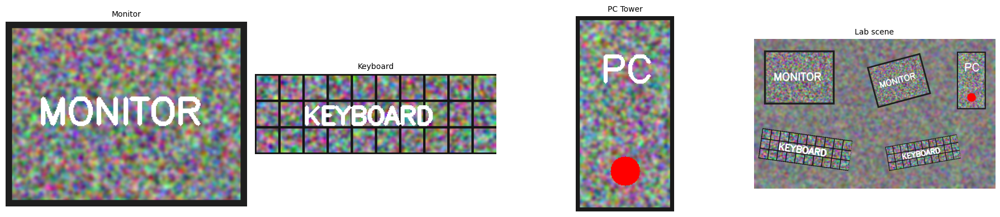

In [4]:
def make_monitor():
    t = make_texture(200, 260, seed=1, blur=2)
    cv2.rectangle(t, (0, 0), (259, 199), (30, 30, 30), 12)
    cv2.putText(t, "MONITOR", (35, 110), FONT, 1.3, (255, 255, 255), 3)
    return t

def make_keyboard():
    t = make_texture(100, 300, seed=2, blur=2)
    for x in range(0, 300, 30):
        cv2.line(t, (x, 0), (x, 99), (20, 20, 20), 2)
    for y in range(0, 100, 33):
        cv2.line(t, (0, y), (299, y), (20, 20, 20), 2)
    cv2.putText(t, "KEYBOARD", (60, 62), FONT, 1.0, (255, 255, 255), 3)
    return t

def make_tower():
    t = make_texture(240, 120, seed=3, blur=2)
    cv2.circle(t, (60, 190), 18, (0, 0, 255), -1)
    cv2.putText(t, "PC", (30, 80), FONT, 1.5, (255, 255, 255), 4)
    cv2.rectangle(t, (0, 0), (119, 239), (25, 25, 25), 8)
    return t

templates = {"Monitor": make_monitor(), "Keyboard": make_keyboard(), "PC Tower": make_tower()}

scene = cv2.addWeighted(make_texture(500, 800, seed=99, blur=4), 0.5, np.full((500, 800, 3), 128, np.uint8), 0.5, 0)
place(scene, templates["Monitor"],  (150, 130), 0.9,   0)
place(scene, templates["Monitor"],  (480, 140), 0.7,  15)
place(scene, templates["PC Tower"], (720, 140), 0.8,   0)
place(scene, templates["Keyboard"], (170, 370), 1.0,  -8)
place(scene, templates["Keyboard"], (560, 380), 0.8,  10)

show_grid(list(templates.values()) + [scene], list(templates.keys()) + ["Lab scene"], cols=4, figsize=(18, 4))

Scene keypoints: 2832


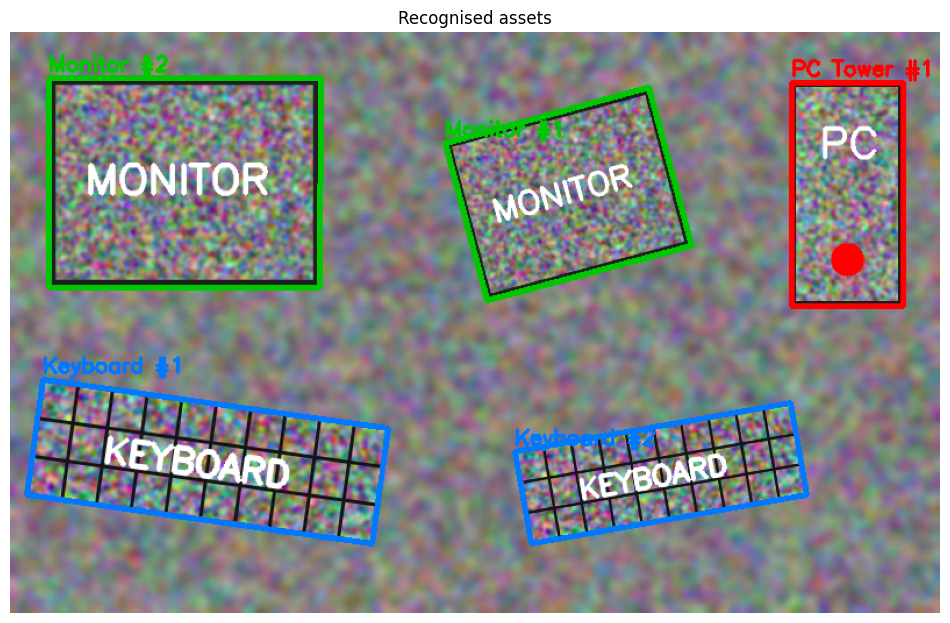


=== INVENTORY ===
Monitor   : 2
Keyboard  : 2
PC Tower  : 1
Total assets: 5


In [5]:
gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
kp_scene, des_scene = sift.detectAndCompute(gray_scene, None)
print("Scene keypoints:", len(kp_scene))

def find_instances(tmpl, min_inliers=12, max_instances=5):
    g = cv2.cvtColor(tmpl, cv2.COLOR_BGR2GRAY)
    kp_t, des_t = sift.detectAndCompute(g, None)
    kps, des = list(kp_scene), des_scene.copy()
    h, w = g.shape
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    found = []
    for _ in range(max_instances):
        if len(kps) < 10:
            break
        good = ratio_matches(des_t, des, 0.75)
        if len(good) < min_inliers:
            break
        src = np.float32([kp_t[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kps[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        Hm, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if Hm is None or int(mask.sum()) < min_inliers:
            break
        quad = cv2.perspectiveTransform(corners, Hm)
        if not cv2.isContourConvex(np.int32(quad)):
            break
        found.append((quad, int(mask.sum())))
        # remove scene keypoints inside the found quad so the next search finds a different copy
        keep = [i for i, k in enumerate(kps) if cv2.pointPolygonTest(quad.astype(np.float32), k.pt, False) < 0]
        kps = [kps[i] for i in keep]
        des = des[keep]
    return found

colors = {"Monitor": (0, 200, 0), "Keyboard": (255, 120, 0), "PC Tower": (0, 0, 255)}
annotated = scene.copy()
inventory = {}
for name, tmpl in templates.items():
    inst = find_instances(tmpl)
    inventory[name] = len(inst)
    for i, (quad, inl) in enumerate(inst, 1):
        cv2.polylines(annotated, [np.int32(quad)], True, colors[name], 3)
        x, y = np.int32(quad[0, 0])
        cv2.putText(annotated, f"{name} #{i}", (x, max(y - 6, 15)), FONT, 0.6, colors[name], 2)

show(annotated, "Recognised assets", figsize=(12, 8))
print("\n=== INVENTORY ===")
for k, v in inventory.items():
    print(f"{k:<10}: {v}")
print("Total assets:", sum(inventory.values()))

### Result explanation
- Every coloured quadrilateral is an asset found by SIFT + homography, even though copies appear at different **scales** (0.7–1.0×) and **rotations** (−8° to +15°).
- The inventory counts each category. In a real lab you would use **photos of the real equipment** as templates (several views per asset type) and run this on every camera frame/photo to keep the inventory current.
- Why homography/RANSAC? Raw descriptor matches always contain some wrong pairs; requiring many matches to agree on one geometric transformation makes false detections very unlikely.

---
# Task 3 – Anomaly Detection in Sensor Data Using Wavelet Transformation

### Idea
A **wavelet transform** splits a signal into an *approximation* (slow, smooth trend) and several levels of *detail* coefficients (fast fluctuations / noise). If we **shrink the small detail coefficients (thresholding)** and rebuild the signal, we get a **denoised** version of normal machine behaviour. Subtracting it from the raw data gives the **residual** – whatever the "normal" model cannot explain. Large residuals = **anomalies**.

### Pipeline
1. Generate 1000 samples of sensor data (Gaussian noise, matching the expected-output figure).
2. `pywt.wavedec(data, 'db4', level=4)` → decompose with a Daubechies-4 wavelet.
3. Estimate the noise level from the finest detail coefficients: σ = median(|cD₁|) / 0.6745 (robust estimator) and compute the **universal threshold** λ = σ·√(2·ln n).
4. **Soft-threshold** all detail coefficients, keep the approximation, and reconstruct with `pywt.waverec` → *denoised signal*.
5. `residual = data − denoised`.
6. Flag points where |residual| > 2·std(residual) as **anomalies**.
7. Plot like the expected output: (top) sensor data vs denoised signal, (bottom) residuals with anomalies marked.

noise sigma = 0.987, threshold = 3.667, anomaly limit = +/-1.879
Anomalies detected: 55


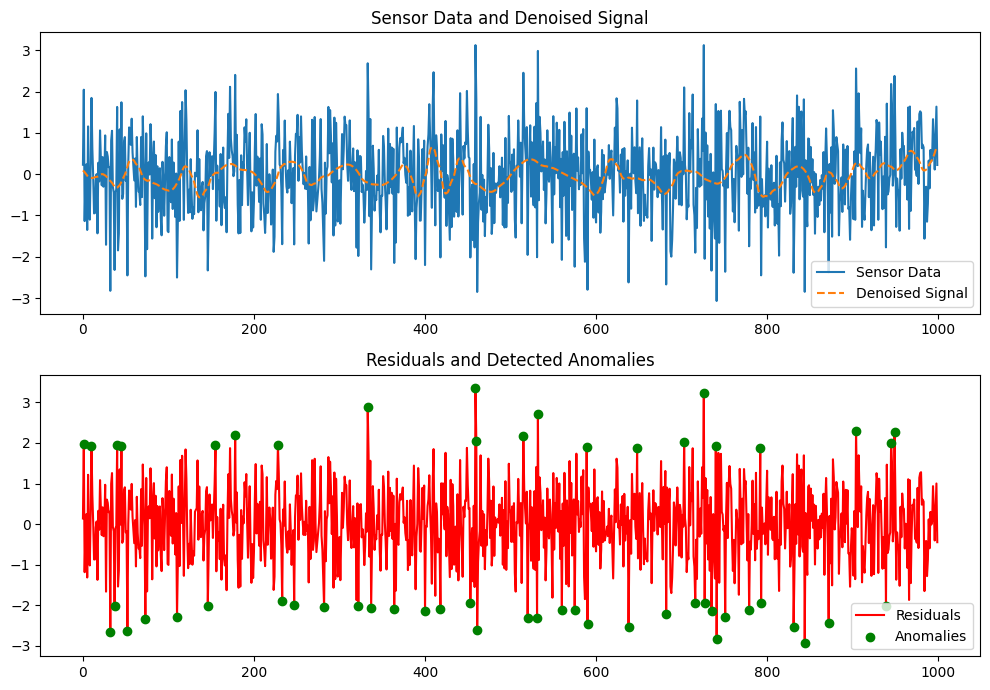

In [6]:
n = 1000
t = np.arange(n)
sensor = np.random.normal(0, 1, n)                      # simulated sensor reading

wavelet, level = "db4", 4
coeffs = pywt.wavedec(sensor, wavelet, level=level)

sigma = np.median(np.abs(coeffs[-1])) / 0.6745          # robust noise estimate
thr = sigma * np.sqrt(2 * np.log(n))                    # universal threshold
den_coeffs = [coeffs[0]] + [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
denoised = pywt.waverec(den_coeffs, wavelet)[:n]

residual = sensor - denoised
limit = 2 * np.std(residual)
anom_idx = np.where(np.abs(residual) > limit)[0]
print(f"noise sigma = {sigma:.3f}, threshold = {thr:.3f}, anomaly limit = +/-{limit:.3f}")
print("Anomalies detected:", len(anom_idx))

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(t, sensor, label="Sensor Data")
ax[0].plot(t, denoised, "--", label="Denoised Signal")
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")
ax[1].plot(t, residual, "r", label="Residuals")
ax[1].scatter(anom_idx, residual[anom_idx], c="green", zorder=3, label="Anomalies")
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

### Result explanation
- **Top plot:** the raw data is pure noise, so thresholding removes almost all detail coefficients and the denoised line stays near 0 – exactly like the expected output.
- **Bottom plot:** residuals ≈ raw data; the green dots are samples beyond ±2σ (about 5 % for Gaussian noise).

The next cell shows a more realistic case: a periodic machine signal with a few injected faults. Here the wavelet model tracks the *normal* sine wave, so the residual is small everywhere except at the faults, and the detector isolates them cleanly (using a stricter 4σ rule on a robust MAD-based σ).

Injected faults at: [150, 400, 620, 810]
Detected anomalies at: [150, 400, 620, 810]


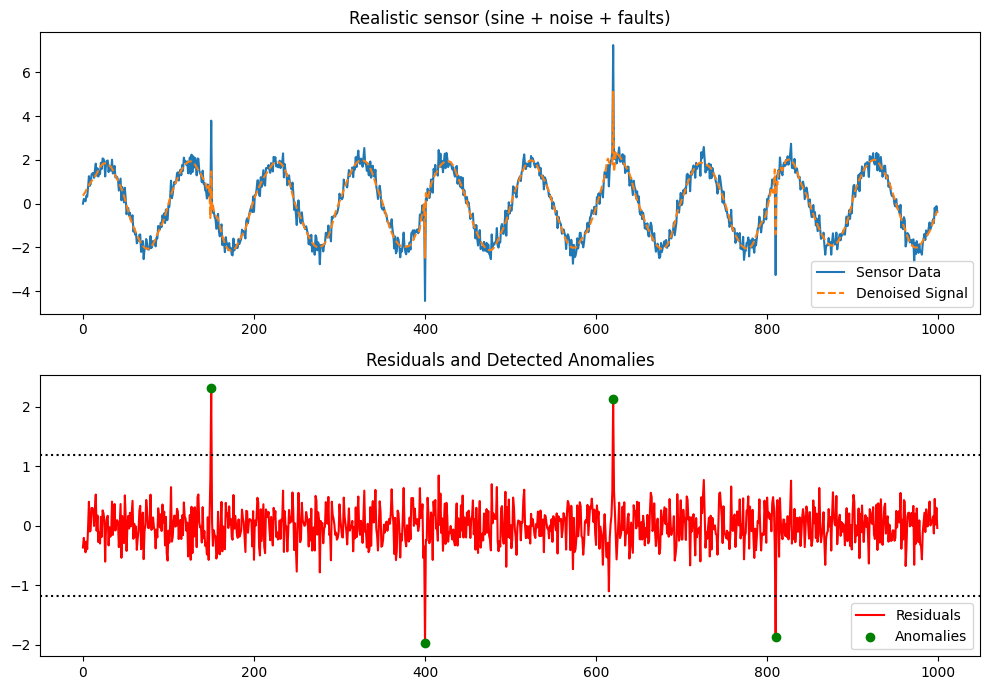

In [7]:
rng = np.random.default_rng(7)
clean = np.sin(2 * np.pi * t / 100) * 2
data2 = clean + rng.normal(0, 0.3, n)
fault_idx = [150, 400, 620, 810]
data2[fault_idx] += np.array([4, -4.5, 5, -4])          # injected machine faults

c2 = pywt.wavedec(data2, "db4", level=4)
s2 = np.median(np.abs(c2[-1])) / 0.6745
den2 = pywt.waverec([c2[0]] + [pywt.threshold(c, s2 * np.sqrt(2 * np.log(n)), "soft") for c in c2[1:]], "db4")[:n]
res2 = data2 - den2
robust_sigma = np.median(np.abs(res2 - np.median(res2))) / 0.6745
anom2 = np.where(np.abs(res2) > 4 * robust_sigma)[0]
print("Injected faults at:", fault_idx)
print("Detected anomalies at:", anom2.tolist())

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(t, data2, label="Sensor Data"); ax[0].plot(t, den2, "--", label="Denoised Signal")
ax[0].set_title("Realistic sensor (sine + noise + faults)"); ax[0].legend(loc="lower right")
ax[1].plot(t, res2, "r", label="Residuals"); ax[1].scatter(anom2, res2[anom2], c="green", zorder=3, label="Anomalies")
ax[1].axhline(4 * robust_sigma, ls=":", c="k"); ax[1].axhline(-4 * robust_sigma, ls=":", c="k")
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

---
# Task 4 – Object Recognition (Using Video) with SIFT

### Idea
Same SIFT principle as Task 2, but applied to **every frame of a video**: we compute the reference object's SIFT features **once**, then in each frame match them and use a **homography** to locate the object and draw its bounding box – even when it changes **scale**, **orientation** or is **partially occluded** (a homography only needs ≥ 4 good matches, so the visible part is enough).

### Pipeline
1. Reference image of the object → keypoints + descriptors (computed once).
2. Create a test video (`test_video.avi`): the object moves, grows/shrinks, rotates, and in frames 35-45 half of it is covered by a grey box (occlusion). *(To use your own video set `VIDEO_PATH` and `REF_PATH`.)*
3. For each frame: SIFT → **FLANN** (fast approximate nearest-neighbour; kd-tree) matching → ratio test → `findHomography(RANSAC)`.
4. Accept the detection only if inliers ≥ 10 **and** the projected box is convex (rejects nonsense homographies).
5. Draw the bounding box (green) and write the annotated frames to `recognized_output.avi`.

Reference keypoints: 399


Object located in 60/60 frames  ->  saved: recognized_output.avi


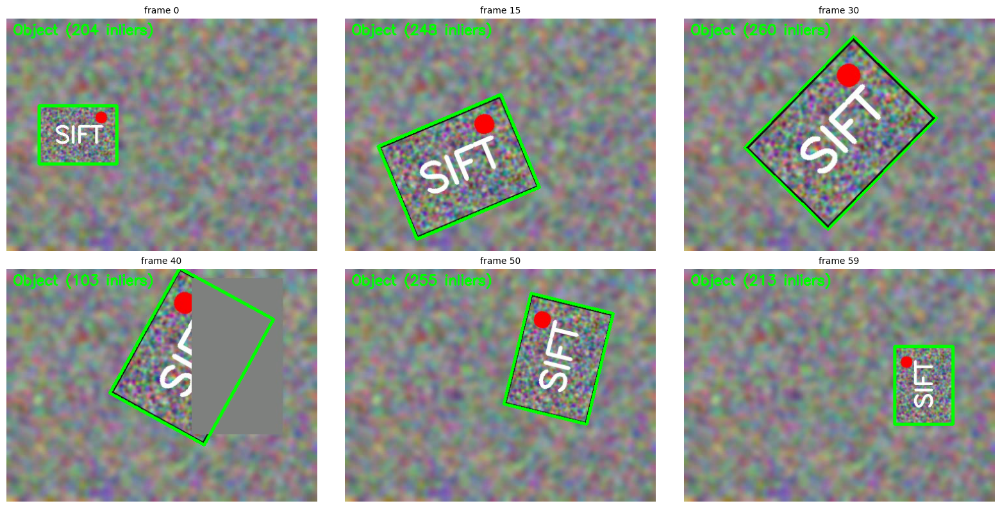

In [8]:
VIDEO_PATH, REF_PATH = None, None       # set both to use your own video + reference image

def make_reference():
    ref = make_texture(150, 200, seed=5, blur=2)
    cv2.rectangle(ref, (0, 0), (199, 149), (20, 20, 20), 6)
    cv2.putText(ref, "SIFT", (40, 95), FONT, 2, (255, 255, 255), 5)
    cv2.circle(ref, (160, 30), 15, (0, 0, 255), -1)
    return ref

def make_video(path, ref, n_frames=60, size=(480, 360)):
    bg = cv2.addWeighted(make_texture(size[1], size[0], seed=7, blur=5), 0.6, np.full((size[1], size[0], 3), 128, np.uint8), 0.4, 0)
    out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"MJPG"), 15, size)
    for i in range(n_frames):
        p = i / (n_frames - 1)
        frame = bg.copy()
        scale = 0.6 + 0.6 * math.sin(math.pi * p)                # change of scale
        angle = 90 * p                                            # change of orientation
        centre = (110 + 260 * p, 180 + 50 * math.sin(2 * math.pi * p))
        place(frame, ref, centre, scale, angle)
        if 35 <= i <= 45:                                         # partial occlusion
            cx = int(centre[0])
            cv2.rectangle(frame, (cx, int(centre[1]) - 120), (cx + 140, int(centre[1]) + 120), (128, 128, 128), -1)
        out.write(frame)
    out.release()

if REF_PATH and VIDEO_PATH and os.path.exists(REF_PATH) and os.path.exists(VIDEO_PATH):
    ref_img, video_file = cv2.imread(REF_PATH), VIDEO_PATH
else:
    ref_img, video_file = make_reference(), "test_video.avi"
    make_video(video_file, ref_img)

# reference features (once)
ref_gray = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY)
kp_ref, des_ref = sift.detectAndCompute(ref_gray, None)
rh, rw = ref_gray.shape
ref_corners = np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2)
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))   # algorithm=1 -> KD-tree
print("Reference keypoints:", len(kp_ref))

def locate(frame, min_inliers=10):
    g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp_f, des_f = sift.detectAndCompute(g, None)
    if des_f is None or len(kp_f) < 5:
        return None
    pairs = flann.knnMatch(des_ref, des_f, k=2)
    good = [p[0] for p in pairs if len(p) == 2 and p[0].distance < 0.7 * p[1].distance]
    if len(good) < min_inliers:
        return None
    src = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp_f[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    Hm, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if Hm is None or int(mask.sum()) < min_inliers:
        return None
    box = cv2.perspectiveTransform(ref_corners, Hm)
    if not cv2.isContourConvex(np.int32(box)):
        return None
    return box, int(mask.sum())

cap = cv2.VideoCapture(video_file)
fw, fh = int(cap.get(3)), int(cap.get(4))
writer = cv2.VideoWriter("recognized_output.avi", cv2.VideoWriter_fourcc(*"MJPG"), 15, (fw, fh))
samples, sample_titles, detected, idx = [], [], 0, 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    res = locate(frame)
    if res is not None:
        box, inl = res
        detected += 1
        cv2.polylines(frame, [np.int32(box)], True, (0, 255, 0), 3)
        cv2.putText(frame, f"Object ({inl} inliers)", (10, 25), FONT, 0.7, (0, 255, 0), 2)
    else:
        cv2.putText(frame, "Object NOT found", (10, 25), FONT, 0.7, (0, 0, 255), 2)
    writer.write(frame)
    if idx in (0, 15, 30, 40, 50, 59):
        samples.append(frame.copy()); sample_titles.append(f"frame {idx}")
    idx += 1
cap.release(); writer.release()
print(f"Object located in {detected}/{idx} frames  ->  saved: recognized_output.avi")
show_grid(samples, sample_titles, cols=3, figsize=(16, 8))

### Result explanation
- The green polygon follows the object while it **moves, scales (≈0.6×–1.2×) and rotates (0°→90°)**. A *polygon* (not an axis-aligned rectangle) is drawn because the homography preserves rotation and perspective.
- Frames 35-45 show **partial occlusion**: only the visible half contributes matches, but that is still enough for a valid homography.
- Frames where the object is lost (e.g. too blurred/occluded) show a red *"NOT found"* message, so you can see the limits of the method.
- **FLANN vs brute force:** FLANN is much faster for many descriptors (real videos) at a tiny cost in exactness; the ratio test keeps the results reliable.

---
# Task 5 – Your Panoramic Image (SIFT image stitching)

### Idea
Overlapping photos of the same scene are related by a **homography** (a 3×3 projective transform). If we find matching SIFT keypoints in the overlap of two images we can compute that homography and **warp one image into the coordinate frame of the other** – repeating this builds a panorama.

### Pipeline
1. Take overlapping images (here: three ~500 px wide crops of one big synthetic scene, 100 px overlap, slightly shifted vertically to mimic a hand-held pan). *Set `IMAGE_PATHS` to use your own photos, ordered left→right.*
2. SIFT keypoints/descriptors for each image.
3. For each neighbour pair (i, i-1): ratio-test matching → `findHomography(RANSAC)` giving **H(i→i-1)**.
4. **Chain** homographies: H(i→0) = H(i-1→0) · H(i→i-1), so every image is expressed in the frame of image 0.
5. Warp the 4 corners of every image to find the **size of the output canvas** and add a translation so no coordinates are negative.
6. Warp all images onto the canvas and **blend with feathering** (weights = distance to the image border) so seams fade smoothly.
7. Crop the black borders created by the vertical shifts.
8. For comparison, OpenCV's built-in `cv2.Stitcher` is also tried.

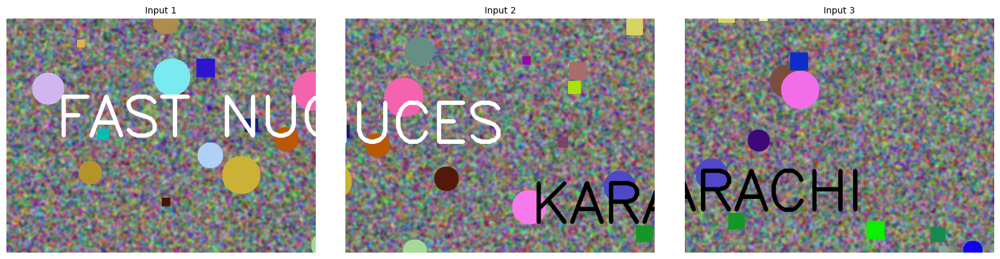

In [9]:
IMAGE_PATHS = None        # e.g. ["p1.jpg", "p2.jpg", "p3.jpg"] ordered left -> right

def make_big_scene():
    big = make_texture(420, 1300, seed=21, blur=2)
    rng = np.random.default_rng(3)
    for _ in range(35):
        c = tuple(int(v) for v in rng.integers(0, 255, 3))
        cx, cy, r = int(rng.integers(0, 1300)), int(rng.integers(0, 420)), int(rng.integers(8, 35))
        cv2.circle(big, (cx, cy), r, c, -1) if rng.random() < 0.5 else cv2.rectangle(big, (cx, cy), (cx + r, cy + r), c, -1)
    cv2.putText(big, "FAST NUCES", (80, 200), FONT, 3, (255, 255, 255), 6)
    cv2.putText(big, "KARACHI", (700, 330), FONT, 3, (0, 0, 0), 6)
    return big

if IMAGE_PATHS and all(os.path.exists(p) for p in IMAGE_PATHS):
    pieces = [cv2.imread(p) for p in IMAGE_PATHS]
    big = None
else:
    big = make_big_scene()
    offsets = [(0, 10), (400, 0), (800, 20)]                                  # (x, y) of each crop
    pieces = [big[y:y + 380, x:x + 500].copy() for x, y in offsets]

show_grid(pieces, [f"Input {i + 1}" for i in range(len(pieces))], cols=3, figsize=(16, 4))

pair (2 -> 1): 371 good matches, 361 inliers
pair (3 -> 2): 382 good matches, 366 inliers
Panorama size (w x h): 1301 x 402


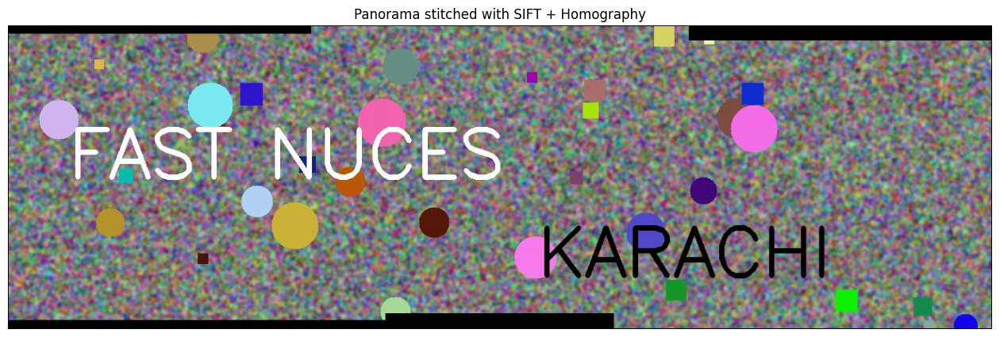

In [10]:
def stitch(images):
    gray = [cv2.cvtColor(im, cv2.COLOR_BGR2GRAY) for im in images]
    feats = [sift.detectAndCompute(g, None) for g in gray]

    # homographies image_i -> image_0
    Hs = [np.eye(3)]
    for i in range(1, len(images)):
        kp_i, des_i = feats[i]
        kp_p, des_p = feats[i - 1]
        good = ratio_matches(des_i, des_p, 0.75)
        print(f"pair ({i + 1} -> {i}): {len(good)} good matches", end="")
        src = np.float32([kp_i[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_p[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        Hm, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
        print(f", {int(mask.sum())} inliers")
        Hs.append(Hs[i - 1] @ Hm)

    # canvas size from warped corners
    allc = []
    for im, Hm in zip(images, Hs):
        h, w = im.shape[:2]
        c = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        allc.append(cv2.perspectiveTransform(c, Hm))
    allc = np.concatenate(allc)
    xmin, ymin = np.floor(allc.min(axis=(0, 1))).astype(int)
    xmax, ymax = np.ceil(allc.max(axis=(0, 1))).astype(int)
    T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float64)
    size = (xmax - xmin, ymax - ymin)

    # feathered blending
    acc = np.zeros((size[1], size[0], 3), np.float32)
    wsum = np.zeros((size[1], size[0]), np.float32)
    for im, Hm in zip(images, Hs):
        h, w = im.shape[:2]
        m = np.ones((h, w), np.uint8); m[0, :] = m[-1, :] = 0; m[:, 0] = m[:, -1] = 0
        wt = cv2.distanceTransform(m, cv2.DIST_L2, 3).astype(np.float32)
        warped = cv2.warpPerspective(im.astype(np.float32), T @ Hm, size)
        wwarp = cv2.warpPerspective(wt, T @ Hm, size)
        acc += warped * wwarp[..., None]
        wsum += wwarp
    pano = (acc / np.maximum(wsum, 1e-6)[..., None]).astype(np.uint8)

    # crop black borders: keep rows that are covered everywhere
    valid = wsum > 0
    rows = np.where(valid.all(axis=1))[0]
    return pano[rows.min():rows.max() + 1] if len(rows) else pano

panorama = stitch(pieces)
print("Panorama size (w x h):", panorama.shape[1], "x", panorama.shape[0])
show(panorama, "Panorama stitched with SIFT + Homography", figsize=(16, 5))

cv2.Stitcher failed with status 1


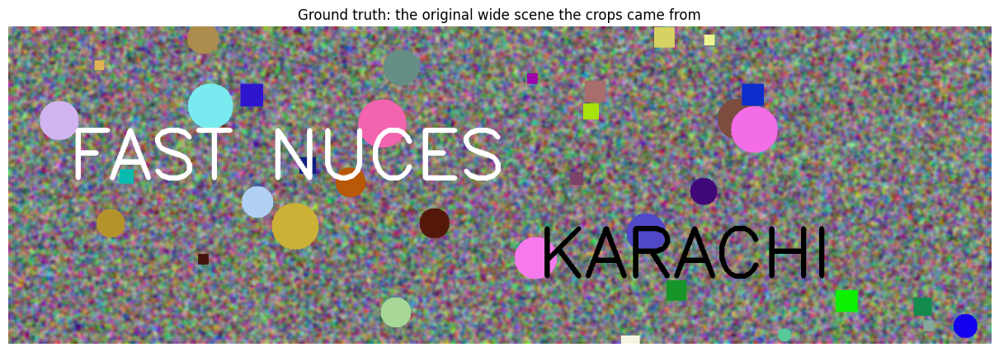

In [11]:
# Optional comparison with OpenCV's built-in high-level stitcher
try:
    status, built_in = cv2.Stitcher_create(cv2.Stitcher_PANORAMA).stitch(pieces)
    if status == cv2.Stitcher_OK:
        show(built_in, "cv2.Stitcher result (for comparison)", figsize=(16, 5))
    else:
        print("cv2.Stitcher failed with status", status)
except Exception as e:
    print("cv2.Stitcher unavailable:", e)
if big is not None:
    show(big, "Ground truth: the original wide scene the crops came from", figsize=(16, 5))

### Result explanation
- The three crops are aligned automatically and merged into one wide image, visually matching the original scene (shown for reference on synthetic data).
- The printed **inliers** per pair show how strong the overlap is. If a pair has < ~15 inliers, stitching will be poor: use ≥ 30-40 % overlap.
- Feather blending hides exposure seams; the black borders caused by the vertical shifts are cropped away.
- With real photos: shoot while rotating around the camera's own axis, keep exposure fixed, and pass the paths in left→right order.

---
# Task 6 – Lane Detection using the Hough Line Transform

### Idea
Lane markings are long, nearly straight bright lines that converge toward the vanishing point. We isolate the edges in the road area and let the Hough transform find the line segments, then merge them into **one left and one right lane line**.

### Pipeline
1. **Grayscale → Gaussian blur → Canny** edges.
2. **Region of interest (ROI):** keep only a trapezoid in front of the vehicle (mask everything else) – this removes sky, horizon and roadside clutter.
3. **`HoughLinesP`** on the masked edges.
4. **Classify by slope:** in image coordinates (y points down) the **left lane has negative slope**, the **right lane has positive slope**. Nearly horizontal or vertical segments (|slope| outside 0.4–3) are discarded as noise.
5. **Average each side:** fit one straight line `x = a·y + b` through all points of that side (`np.polyfit`), which is stable even for vertical lines.
6. Draw the two lane lines from the bottom of the image up to the ROI top, overlay them on the original frame (`addWeighted`).

Two synthetic dashcam images with different road geometry are used (set `IMAGE_PATHS_LANE` to use your own).

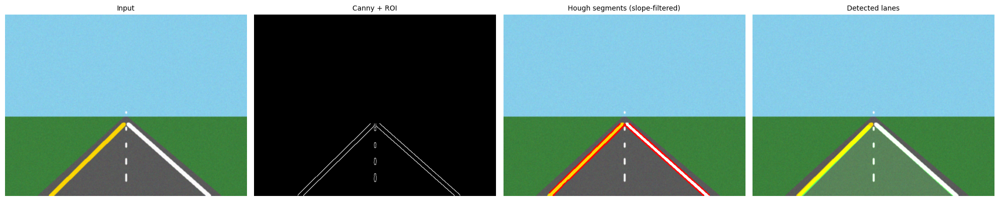

Image 1: lane lines (bottom -> top): {'left': ((124, 480), (307, 297)), 'right': ((537, 480), (335, 297))}


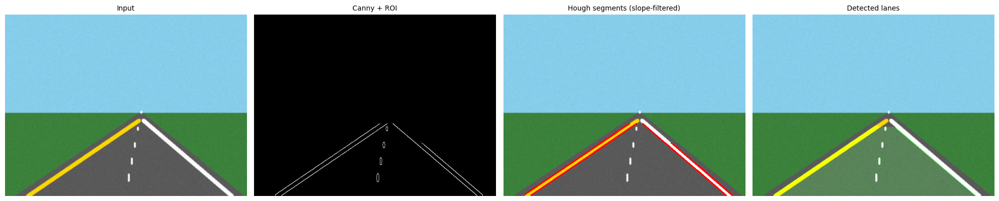

Image 2: lane lines (bottom -> top): {'left': ((59, 480), (328, 297)), 'right': ((599, 480), (383, 297))}


In [12]:
IMAGE_PATHS_LANE = None       # e.g. ["road1.jpg", "road2.jpg"]

def make_road(vp, left_base, right_base, seed):
    h, w = 480, 640
    img = np.zeros((h, w, 3), np.uint8)
    img[:vp[1]] = (235, 206, 135)                                         # sky
    img[vp[1]:] = (90, 90, 90)                                            # asphalt
    for y in range(vp[1], h):                                             # grass-ish verge
        f = (y - vp[1]) / (h - vp[1])
        xl = int(vp[0] + (left_base - vp[0]) * f - 30 * f - 5)
        xr = int(vp[0] + (right_base - vp[0]) * f + 30 * f + 5)
        img[y, :max(xl, 0)] = (60, 130, 60); img[y, min(xr, w):] = (60, 130, 60)
    cv2.line(img, (left_base, h), (vp[0] - 6, vp[1] + 20), (0, 215, 255), 9)    # yellow left line
    cv2.line(img, (right_base, h), (vp[0] + 6, vp[1] + 20), (255, 255, 255), 9) # white right line
    for k in range(5):                                                        # dashed centre line
        y0 = h - 40 - k * 45; f0 = (y0 - vp[1]) / (h - vp[1])
        cv2.line(img, (int(vp[0] + (320 - vp[0]) * f0), y0), (int(vp[0] + (320 - vp[0]) * f0), y0 - int(18 * f0 + 4)), (255, 255, 255), 3)
    rng = np.random.default_rng(seed)
    img = np.clip(img.astype(np.int16) + rng.normal(0, 8, img.shape), 0, 255).astype(np.uint8)
    return cv2.GaussianBlur(img, (3, 3), 0)

if IMAGE_PATHS_LANE and all(os.path.exists(p) for p in IMAGE_PATHS_LANE):
    road_imgs = [cv2.imread(p) for p in IMAGE_PATHS_LANE]
else:
    road_imgs = [make_road((320, 270), 120, 540, 1), make_road((360, 260), 60, 600, 2)]

def detect_lanes(frame):
    h, w = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)

    roi = np.array([[(0, h), (w, h), (int(w * 0.58), int(h * 0.6)), (int(w * 0.42), int(h * 0.6))]], np.int32)
    mask = np.zeros_like(edges); cv2.fillPoly(mask, roi, 255)
    masked = cv2.bitwise_and(edges, mask)

    segs = cv2.HoughLinesP(masked, 1, np.pi / 180, threshold=30, minLineLength=30, maxLineGap=25)
    left, right = [], []                                   # lists of (x, y) points
    raw = frame.copy()
    if segs is not None:
        for x1, y1, x2, y2 in segs[:, 0]:
            if x2 == x1:
                continue
            slope = (y2 - y1) / (x2 - x1)
            if not 0.4 < abs(slope) < 3:
                continue
            cv2.line(raw, (x1, y1), (x2, y2), (0, 0, 255), 2)
            (left if slope < 0 else right).extend([(x1, y1), (x2, y2)])

    out = frame.copy(); lane_layer = np.zeros_like(frame)
    y_bot, y_top = h, int(h * 0.62)
    ends = {}
    for name, pts in (("left", left), ("right", right)):
        if len(pts) >= 2:
            ys, xs = np.array(pts)[:, 1], np.array(pts)[:, 0]
            a, b = np.polyfit(ys, xs, 1)                  # x = a*y + b
            ends[name] = ((int(a * y_bot + b), y_bot), (int(a * y_top + b), y_top))
            cv2.line(lane_layer, *ends[name], (0, 255, 0), 10)
    if len(ends) == 2:                                    # fill the lane area softly
        poly = np.array([ends["left"][0], ends["left"][1], ends["right"][1], ends["right"][0]], np.int32)
        fill = np.zeros_like(frame); cv2.fillPoly(fill, [poly], (0, 120, 0))
        out = cv2.addWeighted(out, 1, fill, 0.35, 0)
    out = cv2.addWeighted(out, 1, lane_layer, 1, 0)
    return edges, masked, raw, out, ends

for i, img in enumerate(road_imgs, 1):
    edges, masked, raw, out, ends = detect_lanes(img)
    show_grid([img, masked, raw, out], ["Input", "Canny + ROI", "Hough segments (slope-filtered)", "Detected lanes"], cols=4, figsize=(20, 4))
    print(f"Image {i}: lane lines (bottom -> top):", ends)

### Result explanation
- **Canny + ROI** leaves only the lane borders (and some noise) in front of the car.
- **Hough segments** (red) are many short pieces along each lane border; the dashed centre line and the horizon are rejected by the slope/ROI filters.
- **Averaging** gives one clean green line per side plus a translucent lane area, which a lane-keeping controller can use: e.g. the offset between the lane centre and the image centre gives the steering error.
- Works on both geometries without changing parameters. For real roads add colour thresholding (white/yellow in HLS) and temporal smoothing across video frames for extra robustness.

---
# Task 7 – Coins Detection and Counting (Hough Circle Transform)

### Idea
The **Hough Circle Transform** is the circle version of the line transform: each edge pixel votes for possible circle centres at a distance `r`; peaks in the accumulator are circle centres. `cv2.HoughCircles` implements this efficiently (gradient method).

### Pipeline
1. Grayscale + **median blur** (removes noise but keeps edges; essential, otherwise many false circles appear).
2. `cv2.HoughCircles(..., HOUGH_GRADIENT, dp, minDist, param1, param2, minRadius, maxRadius)`:
   - `dp` – accumulator resolution ratio (1.2 = slightly coarser, more tolerant);
   - `minDist` – minimum distance between centres (so one coin is not reported twice);
   - `param1` – upper Canny threshold;
   - `param2` – accumulator threshold: **lower → more (possibly false) circles, higher → stricter**;
   - `minRadius / maxRadius` – size range of the coins.
3. Draw each circle and its centre, number them, and show the **count**.
4. Bonus: group the coins into **small / medium / large** by radius (coins of the same denomination have the same radius).

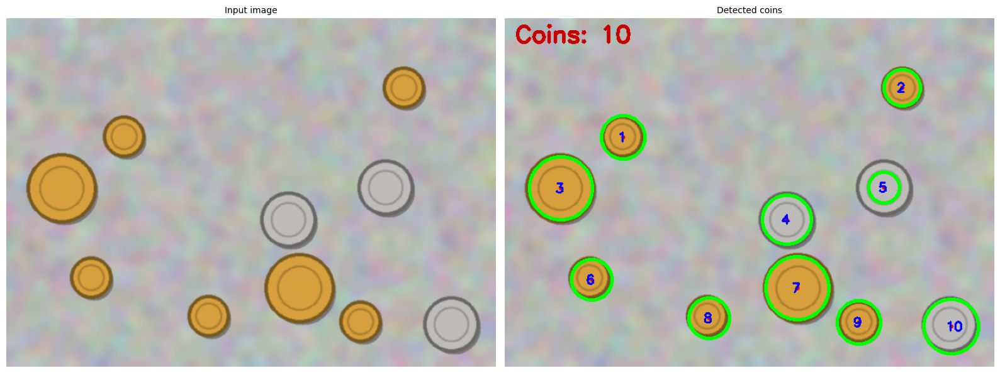

Detected coins: 10 | ground truth: 10
Size classes (by radius): {'small': 6, 'medium': 2, 'large': 2}


In [13]:
IMAGE_PATH_COINS = None     # e.g. "coins.jpg"

def make_coins_image(n=10, size=(500, 700)):
    rng = np.random.default_rng(11)
    bg = cv2.addWeighted(make_texture(size[0], size[1], seed=4, blur=8), 0.25, np.full((size[0], size[1], 3), 200, np.uint8), 0.75, 0)
    placed = []
    radii_choices = [28, 38, 48]
    while len(placed) < n:
        r = int(rng.choice(radii_choices))
        x, y = int(rng.integers(r + 15, size[1] - r - 15)), int(rng.integers(r + 15, size[0] - r - 15))
        if all(math.hypot(x - px, y - py) > r + pr + 12 for px, py, pr in placed):
            placed.append((x, y, r))
    for x, y, r in placed:
        base = (60, 160, 215) if r != 38 else (185, 188, 190)               # gold / silver look
        cv2.circle(bg, (x + 4, y + 5), r, (120, 120, 120), -1)              # soft shadow
        cv2.circle(bg, (x, y), r, base, -1)
        cv2.circle(bg, (x, y), r, tuple(int(c * 0.55) for c in base), 3)    # rim
        cv2.circle(bg, (x, y), int(r * 0.65), tuple(int(c * 0.8) for c in base), 2)
    return cv2.GaussianBlur(bg, (3, 3), 0), placed

if IMAGE_PATH_COINS and os.path.exists(IMAGE_PATH_COINS):
    coins_img, truth = cv2.imread(IMAGE_PATH_COINS), None
else:
    coins_img, truth = make_coins_image(10)

gray = cv2.cvtColor(coins_img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=45,
                           param1=120, param2=40, minRadius=20, maxRadius=65)

result = coins_img.copy()
count = 0
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    count = len(circles)
    for i, (x, y, r) in enumerate(sorted(circles.tolist(), key=lambda c: (c[1] // 100, c[0])), 1):
        cv2.circle(result, (x, y), r, (0, 255, 0), 3)
        cv2.circle(result, (x, y), 3, (0, 0, 255), -1)
        cv2.putText(result, str(i), (x - 8, y + 6), FONT, 0.6, (255, 0, 0), 2)

cv2.putText(result, f"Coins: {count}", (15, 35), FONT, 1.1, (0, 0, 200), 3)
show_grid([coins_img, result], ["Input image", "Detected coins"], cols=2, figsize=(16, 6))
print("Detected coins:", count, "| ground truth:", "unknown" if truth is None else len(truth))

# bonus: size classes
if count:
    radii = np.sort(circles[:, 2])
    small_t, large_t = 33, 43
    cls = {"small": int((radii < small_t).sum()),
           "medium": int(((radii >= small_t) & (radii < large_t)).sum()),
           "large": int((radii >= large_t).sum())}
    print("Size classes (by radius):", cls)

### Result explanation
- Each green circle is a detected coin, the red dot its centre, and the number is its index; the total count is printed on the image and in the console.
- On the synthetic image the detected count equals the ground truth (10 coins). The inner decorative ring of each coin could produce a second circle, but `minDist` suppresses it.
- Grouping by radius lets you tell denominations apart and estimate a total value.
- **Tuning on real photos:** if coins are missed lower `param2`; if you get phantom circles raise `param2` or blur more; set `minRadius/maxRadius` from the known coin size in pixels. Touching coins need a smaller `minDist`.

---
# Task 8 – Smart Security System (boundary detection in a security zone + alarm)

### Idea
We watch a **fixed camera**. Anything that is *not* part of the static background is a candidate "unauthorized object". We find its **boundary (contour)** and trigger an **alarm if that boundary overlaps a predefined security zone**.

### Pipeline
1. Define the **security zone** as a polygon (red) in image coordinates.
2. **Background subtraction (MOG2)**: the model learns the empty scene during a warm-up period (first 30 frames), then its learning rate is set to 0 so a stationary intruder is not absorbed into the background.
3. Clean the foreground mask: Gaussian blur → threshold → **morphological opening** (removes speckle) → **dilation** (fills holes).
4. `cv2.findContours` → keep contours with area > 500 px → **object boundaries** (drawn with `drawContours` + bounding box).
5. **Zone test:** fill the contour in a mask, AND it with the zone mask; if the overlap area > 50 px the object is *inside the zone* → **ALARM** (boundary turns red, "ALARM!" overlay). Otherwise it is only *tracked* (yellow).
6. The same `process_frame` function works on a live webcam: see the `run_live()` function at the end (defined, not executed here because notebooks usually have no camera).

A synthetic video stream is used: an object walks in from the left, crosses the zone and leaves on the right.

Alarm active in frames: (60, 'to', 89)


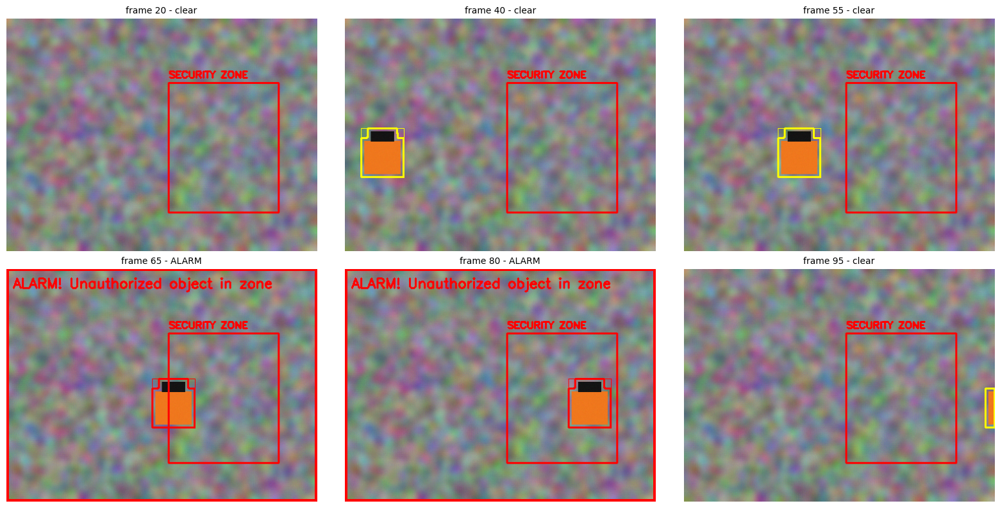

In [14]:
FW, FH = 480, 360
background = cv2.addWeighted(make_texture(FH, FW, seed=11, blur=6), 0.5, np.full((FH, FW, 3), 140, np.uint8), 0.5, 0)
zone_poly = np.array([[250, 100], [420, 100], [420, 300], [250, 300]], np.int32)
zone_mask = np.zeros((FH, FW), np.uint8); cv2.fillPoly(zone_mask, [zone_poly], 255)

def synth_frame(i, rng=np.random.default_rng(0)):
    f = background.copy()
    if i >= 30:                                           # object appears after the warm-up
        x = -50 + 8 * (i - 30)
        cv2.rectangle(f, (x, 190), (x + 55, 240), (30, 120, 240), -1)       # an orange "bag"
        cv2.rectangle(f, (x + 10, 175), (x + 45, 190), (20, 20, 20), -1)    # handle
    f = np.clip(f.astype(np.int16) + rng.normal(0, 2, f.shape), 0, 255).astype(np.uint8)
    return f

frames = [synth_frame(i) for i in range(100)]

mog = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=40, detectShadows=False)
kernel = np.ones((5, 5), np.uint8)

def process_frame(frame, idx, warmup=30):
    fg = mog.apply(cv2.GaussianBlur(frame, (5, 5), 0), learningRate=0.05 if idx < warmup else 0)
    fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)[1]
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)
    fg = cv2.dilate(fg, kernel, iterations=2)
    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out, alarm = frame.copy(), False
    cv2.polylines(out, [zone_poly], True, (0, 0, 255), 2)
    cv2.putText(out, "SECURITY ZONE", (zone_poly[0][0], zone_poly[0][1] - 8), FONT, 0.5, (0, 0, 255), 2)
    if idx >= warmup:
        for cnt in contours:
            if cv2.contourArea(cnt) < 500:
                continue
            obj_mask = np.zeros((FH, FW), np.uint8); cv2.drawContours(obj_mask, [cnt], -1, 255, -1)
            inside = cv2.countNonZero(cv2.bitwise_and(obj_mask, zone_mask)) > 50
            colour = (0, 0, 255) if inside else (0, 255, 255)
            cv2.drawContours(out, [cnt], -1, colour, 2)                       # object boundary
            x, y, w, h = cv2.boundingRect(cnt); cv2.rectangle(out, (x, y), (x + w, y + h), colour, 1)
            alarm |= inside
    if alarm:
        cv2.putText(out, "ALARM! Unauthorized object in zone", (10, 30), FONT, 0.7, (0, 0, 255), 2)
        cv2.rectangle(out, (0, 0), (FW - 1, FH - 1), (0, 0, 255), 6)
    return out, alarm, fg

outs, alarms, masks = [], [], []
for i, f in enumerate(frames):
    o, a, m = process_frame(f, i)
    outs.append(o); alarms.append(a); masks.append(m)

alarm_frames = [i for i, a in enumerate(alarms) if a]
print("Alarm active in frames:", (alarm_frames[0], "to", alarm_frames[-1]) if alarm_frames else "never")
sel = [20, 40, 55, 65, 80, 95]
show_grid([outs[i] for i in sel], [f"frame {i} - " + ("ALARM" if alarms[i] else "clear") for i in sel], cols=3, figsize=(16, 8))

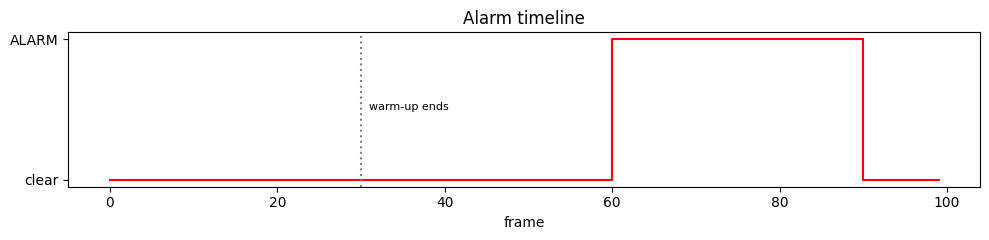

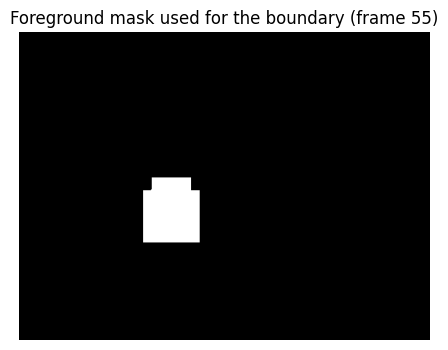

In [15]:
plt.figure(figsize=(10, 2.5))
plt.step(range(len(alarms)), [int(a) for a in alarms], where="post", color="red")
plt.axvline(30, ls=":", c="gray"); plt.text(31, 0.5, "warm-up ends", fontsize=8)
plt.yticks([0, 1], ["clear", "ALARM"]); plt.xlabel("frame"); plt.title("Alarm timeline")
plt.tight_layout(); plt.show()
show(masks[55], "Foreground mask used for the boundary (frame 55)", figsize=(6, 4))

# ---- Live version (needs a webcam; not executed automatically) ----
def run_live(source=0):
    # In the live case FW/FH/zone_poly must match the camera resolution; press 'q' to quit.
    cap = cv2.VideoCapture(source); i = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        frame = cv2.resize(frame, (FW, FH))
        out, alarm, _ = process_frame(frame, i); i += 1
        if alarm: print("\a", end="")                  # terminal beep; replace with playsound/winsound if desired
        cv2.imshow("Smart Security", out)
        if cv2.waitKey(1) & 0xFF == ord("q"): break
    cap.release(); cv2.destroyAllWindows()

### Result explanation
- **Frames 0-29 (warm-up):** no object, the background model learns the empty scene.
- **Yellow boundary:** the object is detected and tracked while *outside* the zone → no alarm.
- **Red boundary + ALARM banner:** as soon as the object's boundary overlaps the red security zone the alarm is raised; it clears when the object leaves (see timeline).
- The alarm uses the object's *actual contour overlap*, not just its bounding box, so objects that only graze the zone's corner don't cause false alarms.
- **Improvements for real deployments:** shadow handling (`detectShadows=True`), ignore people if authorised (add classification), debounce the alarm (require N consecutive frames) and send notifications/sound a siren inside `run_live`.

---
# Summary
| Task | Key functions | Output |
|------|---------------|--------|
| 1 Screen detection | `Canny`, `HoughLinesP`, `findContours` | ON/OFF/MISSING screen map |
| 2 Asset tracking | `SIFT`, `BFMatcher`, `findHomography` | Inventory with counts |
| 3 Wavelet anomalies | `pywt.wavedec/waverec`, thresholding | Denoised signal + anomaly markers |
| 4 Video recognition | `SIFT`, `FlannBasedMatcher`, `perspectiveTransform` | Annotated video |
| 5 Panorama | `SIFT`, chained homographies, `warpPerspective` | Stitched panorama |
| 6 Lane detection | `Canny`, ROI mask, `HoughLinesP`, `polyfit` | Left/right lane overlay |
| 7 Coin counting | `medianBlur`, `HoughCircles` | Count + size classes |
| 8 Security system | `MOG2`, `findContours`, mask overlap | Boundary + alarm |